# peclet quick start — Stokes flow past a sphere

A self-contained first run of **peclet-flow**: creeping flow through a periodic array of spheres, driven by
a pressure gradient, on the multicore-CPU wheel from PyPI. The whole notebook takes about half a minute on
two cores.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-engineering/peclet/blob/main/docs/notebooks/quickstart_sphere.ipynb)

The first cell installs the family (`peclet-flow`, `-pnm`, `-dem`, `-voro`, `-morton`). Use the CPU wheels
here even on a GPU runtime: the CUDA wheels (`peclet-cu13`) need a CUDA 13 capable NVIDIA driver, and
Colab's GPU runtimes currently ship an older one.

In [1]:
%pip install -q peclet

Note: you may need to restart the kernel to use updated packages.


## Geometry

peclet describes solids by a **signed distance field** sampled at the cell centres: negative inside the
solid, positive in the fluid. A sphere of radius `R` in a box of `N`³ cells; the box is periodic, so this
is a cubic lattice of spheres.

In [2]:
import numpy as np
import peclet.flow as flow

N, R = 48, 9.0
x = np.arange(N)
X, Y, Z = np.meshgrid(x, x, x, indexing="ij")
sdf = np.sqrt((X - N / 2) ** 2 + (Y - N / 2) ** 2 + (Z - N / 2) ** 2) - R   # < 0 inside the solid
print("solid fraction:", (sdf < 0).mean().round(3))

solid fraction: 0.027


## Solve

Creeping (Stokes) flow — advection is off by default. The body force is the driving pressure gradient along
`x`; with a large time step the implicit solver marches straight to the steady state, so a few dozen steps
suffice. `set_solid` builds the no-slip cut-cell immersed boundary and the matching pressure operator.

In [3]:
s = flow.Solver(N, N, N)
s.set_rho(1.0); s.set_mu(0.1); s.set_dt(60.0)
s.set_body_force(1e-3, 0.0, 0.0)
s.set_solid(sdf, cutcell_pressure=True)
for _ in range(40):
    s.step()
u, v, w, p = s.get_u(), s.get_v(), s.get_w(), s.get_p()   # numpy arrays indexed [x, y, z]
print(f"backend {flow.execution_space}; mean u = {u.mean():.3e}, max |u| = {np.abs(u).max():.3e}")

backend OpenMP; mean u = 1.571e+00, max |u| = 2.174e+00


## A look at the flow

Speed and streamlines on the mid-plane through the sphere centre. The white disk is the sphere; the flow
speeds up in the gaps between neighbouring spheres of the periodic lattice.

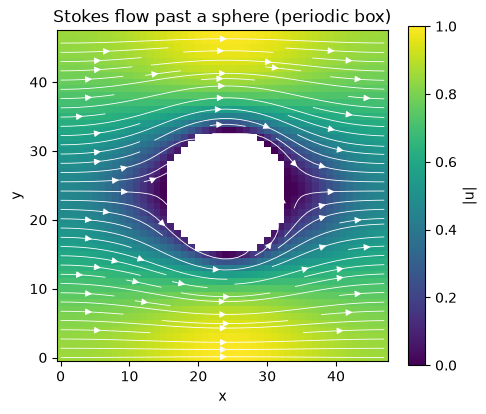

In [4]:
import matplotlib.pyplot as plt

k = N // 2
speed = np.hypot(u[:, :, k], v[:, :, k])
plt.figure(figsize=(5, 4.2))
plt.imshow(np.ma.masked_where(sdf[:, :, k] < 0, speed).T, origin="lower", cmap="viridis")
plt.streamplot(x, x, u[:, :, k].T, v[:, :, k].T, color="w", density=1.2, linewidth=0.6)
plt.colorbar(label="|u|"); plt.title("Stokes flow past a sphere (periodic box)")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout()

## Where next

- **Darcy permeability:** `k = mu * u.mean() / 1e-3` (in cell units) — compare against the
  [Zick & Homsy](https://computational-chemical-engineering.github.io/peclet-examples/) sphere-array
  reference in the examples gallery.
- Turn on `s.set_advection(True)` and lower `set_dt` for a Navier–Stokes run; `s.set_domain_bc(face, type)`
  replaces the periodic faces by walls, inflow, outflow or symmetry planes.
- The [Python API reference](https://computational-chemical-engineering.github.io/peclet/python/) lists every
  call; the [examples gallery](https://computational-chemical-engineering.github.io/peclet-examples/) holds
  validated, runnable notebooks for each code.